In [1]:
import pandas as pd

In [2]:
df= pd.read_csv('/content/Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Note : we are not trying to make a perfect model
**(Our EndGoal Is To Implement A Neural-Network)**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.drop(columns =['RowNumber','CustomerId','Surname'],inplace=True)

In [7]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [8]:
df = pd.get_dummies(df,['Geography','Gender'],drop_first=True)

In [9]:
X=df.drop(columns=['Exited'])
y=df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [10]:
X_train


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
2694,628,29,3,113146.98,2,0,1,124749.08,True,False,True
5140,626,29,4,105767.28,2,0,0,41104.82,False,False,False
2568,612,47,6,130024.87,1,1,1,45750.21,True,False,False
3671,646,52,6,111739.40,2,0,1,68367.18,True,False,False
7427,714,33,8,122017.19,1,0,0,162515.17,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...
2895,621,47,7,107363.29,1,1,1,66799.28,True,False,True
7813,684,63,3,81245.79,1,1,0,69643.31,True,False,False
905,672,45,9,0.00,1,1,1,92027.69,False,False,False
5192,663,39,8,0.00,2,1,1,101168.90,False,False,False


In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [29]:
model = Sequential()

model.add(Dense(3,activation='sigmoid',input_dim=11))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### **Generally:** model.add(Dense(NUMBER_OF_NEURONS,activation='ACTIVATION_FUNCTION',input_dim=NUMBER_OF_INPUT_FEATURES))

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
# For Compilation
model.compile(loss ='binary_crossentropy',optimizer = 'Adam')

In [32]:
model.fit(X_train_scaled,y_train,epochs=10)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6151
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5227
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4843
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4656
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4540
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4458
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4397
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4352
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4321
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4299


In [33]:
# Okay Now We have found out the weights and bias after 10 epochs lets see them
model.layers[0].get_weights()

[array([[ 0.04090467,  0.2225443 ,  0.16198744],
        [-1.0672628 , -1.3381729 ,  1.0303404 ],
        [ 0.20315486,  0.0977685 ,  0.3116112 ],
        [-0.17054892, -0.4106792 , -0.00219962],
        [ 0.8663087 , -0.20322508,  0.11775783],
        [-0.25837928,  0.17296004, -0.24323404],
        [ 0.6475027 ,  0.5918013 , -0.7213073 ],
        [-0.1133626 ,  0.00479659,  0.08648261],
        [-0.386665  , -0.59409326,  0.2881394 ],
        [ 0.21381253, -0.3019106 , -0.29068664],
        [ 0.40196994,  0.21952875, -0.79656816]], dtype=float32),
 array([ 0.70611554,  0.46257105, -0.35427845], dtype=float32)]

In [36]:
model.layers[1].get_weights()

[array([[-1.1326407 ],
        [-1.3448318 ],
        [ 0.71128976]], dtype=float32),
 array([-0.41287836], dtype=float32)]

In [37]:
# Now Lets Predict
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [39]:
y_log
# We can observe that since it is a sigmoid function we are getting probablity
# so what we can do for learning prupose we can simply take a threshold of lets say 0.5 and then
# assign 0 and 1 accordingly .(But actually for finding the threshould you would have to plot the roc-auc curve and all)

array([[0.10439095],
       [0.14523411],
       [0.1316978 ],
       ...,
       [0.06991195],
       [0.1254322 ],
       [0.36153123]], dtype=float32)

In [42]:
import numpy as np
y_pred=np.where(y_log<0.5,0,1)


In [43]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.809

Now To Improve This accuracy we can do several things like increasing the number of hidden layers and changing the activation function of hidden layers to relu because it is observed that relu generally gives better results so lets do it and see

In [14]:
model = Sequential()

model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(loss ='binary_crossentropy',optimizer = 'Adam',metrics=['accuracy'])

## **validation_split**:0.2
holds back the last 20% of your training data (before shuffling happens per epoch) and uses it purely to check how the model performs on unseen data after each epoch — it's never used to update the weights, just to monitor if the model is actually learning or starting to overfit.

In [26]:
history = model.fit(X_train_scaled,y_train,epochs=20,validation_split=0.2)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8706 - loss: 0.3143 - val_accuracy: 0.8525 - val_loss: 0.3575
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8727 - loss: 0.3141 - val_accuracy: 0.8519 - val_loss: 0.3570
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8720 - loss: 0.3140 - val_accuracy: 0.8525 - val_loss: 0.3567
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8725 - loss: 0.3143 - val_accuracy: 0.8537 - val_loss: 0.3572
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8709 - loss: 0.3137 - val_accuracy: 0.8494 - val_loss: 0.3581
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8714 - loss: 0.3139 - val_accuracy: 0.8519 - val_loss: 0.3585
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8725 - loss: 0.3134 - val_accuracy: 0.8494 - val_loss: 0.3588
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8728 - loss: 0.3129 - val_accuracy: 0.

If Your accuracy is increasing rapidly and the val_accuracy is still almost same that means it is a overfitting scenario

### **If you confuse b/w x_test and validation split :**
### **validation_split**
carves a piece out of X_train itself, and the model peeks at it after every epoch during training. You (or Keras callbacks like early stopping) use this to tune things — adjust epochs, layers, learning rate, etc. Because you're allowed to react to it and change your model, it's technically not 100% "unseen" in the end — it indirectly influences your choices.
### **X_test**
is a completely separate dataset you set aside before training even starts (usually via train_test_split), and you don't touch it until the very end. It's used exactly once, after all tuning is done, to get an honest, unbiased score of how your model will perform on real-world/unseen data.


In [18]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [19]:
import numpy as np
y_pred=np.where(y_log<0.5,0,1)

In [20]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.859

In [22]:
import matplotlib.pyplot as plt

In [27]:
history.history

{'accuracy': [0.8706250190734863,
  0.8726562261581421,
  0.8720312714576721,
  0.8725000023841858,
  0.8709375262260437,
  0.8714062571525574,
  0.8725000023841858,
  0.8728125095367432,
  0.8731250166893005,
  0.8717187643051147,
  0.8712499737739563,
  0.8717187643051147,
  0.8707812428474426,
  0.8729687333106995,
  0.870312511920929,
  0.8709375262260437,
  0.8709375262260437,
  0.8729687333106995,
  0.8714062571525574,
  0.8709375262260437],
 'loss': [0.31434860825538635,
  0.3140973746776581,
  0.3139627277851105,
  0.3143298029899597,
  0.3136758506298065,
  0.31391218304634094,
  0.3134375214576721,
  0.3129445016384125,
  0.3140806555747986,
  0.3138403296470642,
  0.31347548961639404,
  0.31331372261047363,
  0.3135245144367218,
  0.3132380247116089,
  0.313997745513916,
  0.3131472170352936,
  0.3127099871635437,
  0.3138164281845093,
  0.3133833110332489,
  0.3129900097846985],
 'val_accuracy': [0.8525000214576721,
  0.8518750071525574,
  0.8525000214576721,
  0.8537499904

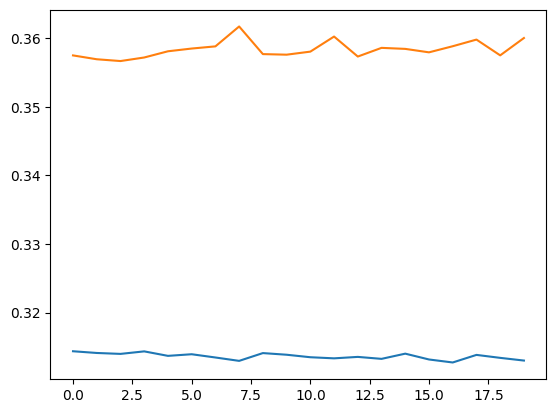

In [29]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()


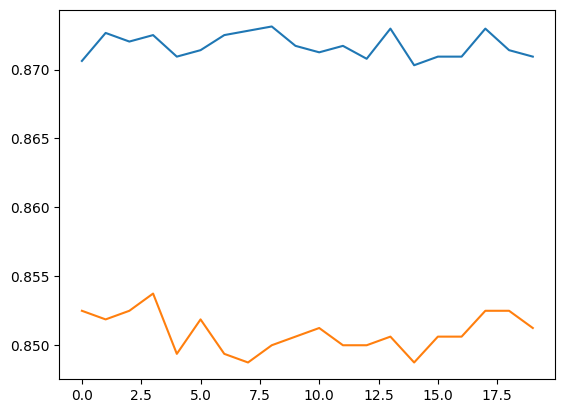

In [30]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()